In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
import statsmodels.api as sm 


In [2]:
df=pd.read_excel(r"C:\Users\Welcome\Downloads\ML\innercity.xlsx")

In [4]:
df.head()

,cid,dayhours,price,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,...,basement,yr_built,yr_renovated,zipcode,lat,long,living_measure15,lot_measure15,furnished,total_area
0,3876100940,20150427T000000,600000,4.0,1.75,3050.0,9440.0,1,0,0.0,...,1250.0,1966,0,98034,47.7228,-122.183,2020.0,8660.0,0.0,12490
1,3145600250,20150317T000000,190000,2.0,1.00,670.0,3101.0,1,0,0.0,...,0.0,1948,0,98118,47.5546,-122.274,1660.0,4100.0,0.0,3771
2,7129303070,20140820T000000,735000,4.0,2.75,3040.0,2415.0,2,1,4.0,...,0.0,1966,0,98118,47.5188,-122.256,2620.0,2433.0,0.0,5455
3,7338220280,20141010T000000,257000,3.0,2.50,1740.0,3721.0,2,0,0.0,...,0.0,2009,0,98002,47.3363,-122.213,2030.0,3794.0,0.0,5461
4,7950300670,20150218T000000,450000,2.0,1.00,1120.0,4590.0,1,0,0.0,...,0.0,1924,0,98118,47.5663,-122.285,1120.0,5100.0,0.0,5710


In [5]:
df.shape

(21613, 23)

In [6]:
df.columns

Index(['cid', 'dayhours', 'price', 'room_bed', 'room_bath', 'living_measure',
       'lot_measure', 'ceil', 'coast', 'sight', 'condition', 'quality',
       'ceil_measure', 'basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'living_measure15', 'lot_measure15', 'furnished',
       'total_area'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cid               21613 non-null  int64  
 1   dayhours          21613 non-null  object 
 2   price             21613 non-null  int64  
 3   room_bed          21505 non-null  float64
 4   room_bath         21505 non-null  float64
 5   living_measure    21596 non-null  float64
 6   lot_measure       21571 non-null  float64
 7   ceil              21571 non-null  object 
 8   coast             21612 non-null  object 
 9   sight             21556 non-null  float64
 10  condition         21556 non-null  object 
 11  quality           21612 non-null  float64
 12  ceil_measure      21612 non-null  float64
 13  basement          21612 non-null  float64
 14  yr_built          21612 non-null  object 
 15  yr_renovated      21613 non-null  int64  
 16  zipcode           21613 non-null  int64 

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cid,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.401822e+05,3.673622e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
room_bed,21505.0,3.371355e+00,9.302886e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
room_bath,21505.0,2.115171e+00,7.702481e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
living_measure,21596.0,2.079861e+03,9.184961e+02,2.900000e+02,1.429250e+03,1.910000e+03,2.550000e+03,1.354000e+04
lot_measure,21571.0,1.510458e+04,4.142362e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068450e+04,1.651359e+06
sight,21556.0,2.343663e-01,7.664376e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
quality,21612.0,7.656857e+00,1.175484e+00,1.000000e+00,7.000000e+00,7.000000e+00,8.000000e+00,1.300000e+01
ceil_measure,21612.0,1.788367e+03,8.281025e+02,2.900000e+02,1.190000e+03,1.560000e+03,2.210000e+03,9.410000e+03
basement,21612.0,2.915225e+02,4.425808e+02,0.000000e+00,0.000000e+00,0.000000e+00,5.600000e+02,4.820000e+03


In [10]:
df.select_dtypes(include='object')


,dayhours,ceil,coast,condition,yr_built,long,total_area
0,20150427T000000,1,0,3,1966,-122.183,12490
1,20150317T000000,1,0,4,1948,-122.274,3771
2,20140820T000000,2,1,3,1966,-122.256,5455
3,20141010T000000,2,0,3,2009,-122.213,5461
4,20150218T000000,1,0,3,1924,-122.285,5710
...,...,...,...,...,...,...,...
21608,20150310T000000,2,0,3,1996,-121.962,63597
21609,20140521T000000,1,0,3,1939,-122.341,5871
21610,20140905T000000,2,0,3,1978,-122.04,38122
21611,20150206T000000,2,0,3,1997,-122.316,9360


# finding strings

In [11]:
df['dayhours'].unique()


array(['20150427T000000', '20150317T000000', '20140820T000000',
       '20141010T000000', '20150218T000000', '20140709T000000',
       '20140715T000000', '20140618T000000', '20140721T000000',
       '20141028T000000', '20140502T000000', '20150123T000000',
       '20141029T000000', '20150311T000000', '20140822T000000',
       '20140522T000000', '20140819T000000', '20150428T000000',
       '20150212T000000', '20140909T000000', '20141125T000000',
       '20140818T000000', '20140719T000000', '20141230T000000',
       '20150112T000000', '20140829T000000', '20150501T000000',
       '20140811T000000', '20141103T000000', '20140620T000000',
       '20141203T000000', '20141030T000000', '20141208T000000',
       '20140903T000000', '20140610T000000', '20150422T000000',
       '20140625T000000', '20150222T000000', '20150113T000000',
       '20140923T000000', '20140624T000000', '20150128T000000',
       '20141014T000000', '20150316T000000', '20140912T000000',
       '20140606T000000', '20141017T0000

In [12]:
df['ceil'].unique()

array([1, 2, 3, 1.5, 2.5, '$', nan, 3.5], dtype=object)

In [13]:
df["coast"].unique()

array([0, 1, '$', nan], dtype=object)

In [14]:
df['condition'].unique()

array([3, 4, 5, 2, nan, 1, '$'], dtype=object)

In [15]:
df['long'].unique()

array([-122.183, -122.274, -122.256, -122.213, -122.285, '$', -122.333,
       -122.165, -122.15, -122.178, -121.87, -122.352, -122.122, -122.275,
       -122.234, -122.324, -122.321, -122.277, -122.196, -122.398,
       -122.019, -122.181, -122.325, -122.191, -122.026, -122.084, -122.3,
       -122.287, -122.011, -122.127, -122.281, -122.221, -121.859,
       -121.913, -122.39, -121.871, -122.013, -122.381, -122.279,
       -122.194, -122.201, -122.125, -122.379, -122.121, -122.024,
       -122.389, -122.305, -122.346, -122.375, -122.344, -122.028,
       -122.193, -122.209, -122.365, -122.28, -122.334, -122.149,
       -122.388, -122.016, -122.298, -122.153, -121.802, -121.878,
       -122.218, -122.359, -122.296, -122.361, -122.357, -122.309,
       -122.056, -121.974, -122.18, -122.331, -122.374, -121.976,
       -121.975, -122.216, -122.188, -122.391, -122.31, -122.302,
       -121.972, -122.22, -122.17, -122.101, -121.888, -122.046, -122.154,
       -122.145, -122.236, -122.168, 

In [16]:
df['yr_built'].unique()

array([1966, 1948, 2009, 1924, 1994, 2005, 1978, 1983, 2012, 1912, 1990,
       1967, 1919, 1908, 1950, 2000, 2013, 1943, 1922, 1977, 2004, 1935,
       1964, 1945, 1987, 2008, 1940, 2003, 1988, 1985, 1998, 1995, 1946,
       1984, 1958, 1963, 1942, 2014, 1971, 1936, 1954, 1923, 2002, 1972,
       2007, 1930, 1962, 1999, 1953, 1965, 2010, 1997, 2006, 1979, 1996,
       1992, 1968, 1980, 1981, 1969, 2001, 1929, 1952, 1916, 1976, 1974,
       1920, 1931, 1975, 1960, 1900, '$', 1986, 1989, 1906, 1955, 1956,
       1915, 1941, 1993, 2011, 1925, 1947, 1991, 1926, 1927, 1951, 1961,
       1932, 1917, 1928, 1959, 1921, 1911, 1949, 1982, 1913, 1957, 1914,
       1938, 1973, 1937, 1944, 1970, 1901, 1907, 1939, 1918, 1934, 1904,
       2015, 1909, 1910, 1905, 1902, 1933, 1903, nan], dtype=object)

In [17]:
df['total_area'].unique()

array([12490, 3771, 5455, ..., 16111, 63597, 38122], dtype=object)

# replacing the strings will null values

In [18]:
df['ceil'] = df['ceil'].replace('$', np.nan)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\1136248646.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ceil'] = df['ceil'].replace('$', np.nan)


In [19]:
df['ceil'].isna().sum()

np.int64(72)

In [20]:
df['ceil']=df['ceil'].astype('float64')

In [21]:
df['ceil']=df['ceil'].fillna(df['ceil'].median())

In [22]:
df['ceil'].isna().sum()

np.int64(0)

In [23]:
df['coast'] = df['coast'].replace('$', np.nan)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\174164141.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['coast'] = df['coast'].replace('$', np.nan)


In [24]:
df['coast'].isna().sum()

np.int64(31)

In [25]:
df['coast']=df['coast'].fillna(df['coast'].median())

In [26]:
df['coast'].isna().sum()

np.int64(0)

In [27]:
df['coast']=df['coast'].astype('float64')

In [28]:
df['condition'] = df['condition'].replace('$', np.nan)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\1725754950.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['condition'] = df['condition'].replace('$', np.nan)


In [29]:
df['condition'].isna().sum()

np.int64(85)

In [30]:
df['condition']=df['condition'].fillna(df['condition'].median())

In [31]:
df['condition'].isna().sum()

np.int64(0)

In [32]:
df['condition']=df['condition'].astype('float64')

In [33]:
df['yr_built'] = df['yr_built'].replace('$', np.nan)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\1111192045.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['yr_built'] = df['yr_built'].replace('$', np.nan)


In [34]:
df['yr_built'].isna().sum()

np.int64(15)

In [35]:
df['yr_built']=df['yr_built'].astype('float64')

In [36]:
df['yr_built']=df['yr_built'].fillna(df['yr_built'].median())

In [37]:
df['yr_built'].isna().sum()

np.int64(0)

In [39]:
df['long'] = df['long'].replace('$', np.nan)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\2049669565.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['long'] = df['long'].replace('$', np.nan)


In [40]:
df['long'].isna().sum()

np.int64(34)

In [41]:
df['long']=df['long'].astype('float64')

In [42]:
df['long']=df['long'].fillna(df['long'].median())

In [43]:
df['long'].isna().sum()

np.int64(0)

In [45]:
df['total_area'].isna().sum()

np.int64(29)

In [46]:
df['total_area'] = df['total_area'].replace('$', np.nan)

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\3256123733.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['total_area'] = df['total_area'].replace('$', np.nan)


In [47]:
df['total_area'].isna().sum()

np.int64(68)

In [48]:
df['total_area']=df['total_area'].astype('float64')

In [49]:
df['total_area']=df['total_area'].fillna(df['total_area'].median())

In [50]:
df['total_area'].isna().sum()

np.int64(0)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cid               21613 non-null  int64  
 1   dayhours          21613 non-null  object 
 2   price             21613 non-null  int64  
 3   room_bed          21505 non-null  float64
 4   room_bath         21505 non-null  float64
 5   living_measure    21596 non-null  float64
 6   lot_measure       21571 non-null  float64
 7   ceil              21613 non-null  float64
 8   coast             21613 non-null  float64
 9   sight             21556 non-null  float64
 10  condition         21613 non-null  float64
 11  quality           21612 non-null  float64
 12  ceil_measure      21612 non-null  float64
 13  basement          21612 non-null  float64
 14  yr_built          21613 non-null  float64
 15  yr_renovated      21613 non-null  int64  
 16  zipcode           21613 non-null  int64 

# Checking if there is null values in other columns

In [52]:
df['coast'].unique()

array([0., 1.])

In [53]:
df['condition'].unique()

array([3., 4., 5., 2., 1.])

In [54]:
df['furnished'].unique()

array([ 0.,  1., nan])

In [55]:
df.isna().sum()

cid                   0
dayhours              0
price                 0
room_bed            108
room_bath           108
living_measure       17
lot_measure          42
ceil                  0
coast                 0
sight                57
condition             0
quality               1
ceil_measure          1
basement              1
yr_built              0
yr_renovated          0
zipcode               0
lat                   0
long                  0
living_measure15    166
lot_measure15        29
furnished            29
total_area            0
dtype: int64

In [56]:
df['room_bed']=df['room_bed'].fillna(df['room_bed'].median())

In [57]:
df['room_bed'].isna().sum()

np.int64(0)

In [58]:
df['room_bath']=df['room_bath'].fillna(df['room_bath'].median())

In [59]:
df['room_bath'].isna().sum()

np.int64(0)

In [60]:
df['living_measure']=df['living_measure'].fillna(df['living_measure'].median())

In [61]:
df['living_measure'].isna().sum()

np.int64(0)

In [62]:
df['lot_measure']=df['lot_measure'].fillna(df['lot_measure'].median())

In [63]:
df['lot_measure'].isna().sum()

np.int64(0)

In [64]:
df['sight']=df['sight'].fillna(df['sight'].median())

In [65]:
df['sight'].isna().sum()

np.int64(0)

In [66]:
df['quality']=df['quality'].fillna(df['quality'].median())

In [67]:
df['quality'].isna().sum()

np.int64(0)

In [68]:
df['ceil_measure']=df['ceil_measure'].fillna(df['ceil_measure'].median())

In [69]:
df['ceil_measure'].isna().sum()

np.int64(0)

In [70]:
df['basement']=df['basement'].fillna(df['basement'].median())

In [71]:
df['basement'].isna().sum()

np.int64(0)

In [72]:
df['living_measure15']=df['living_measure15'].fillna(df['living_measure15'].median())

In [73]:
df['living_measure15'].isna().sum()

np.int64(0)

In [74]:
df['lot_measure15']=df['lot_measure15'].fillna(df['lot_measure15'].median())

In [75]:
df['lot_measure15'].isna().sum()

np.int64(0)

In [76]:
df['furnished']=df['furnished'].fillna(df['furnished'].median())

In [77]:
df['furnished'].isna().sum()

np.int64(0)

In [78]:
df.isna().sum() # checking for null values

cid                 0
dayhours            0
price               0
room_bed            0
room_bath           0
living_measure      0
lot_measure         0
ceil                0
coast               0
sight               0
condition           0
quality             0
ceil_measure        0
basement            0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
living_measure15    0
lot_measure15       0
furnished           0
total_area          0
dtype: int64

In [80]:
df.columns

Index(['cid', 'dayhours', 'price', 'room_bed', 'room_bath', 'living_measure',
       'lot_measure', 'ceil', 'coast', 'sight', 'condition', 'quality',
       'ceil_measure', 'basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'living_measure15', 'lot_measure15', 'furnished',
       'total_area'],
      dtype='object')

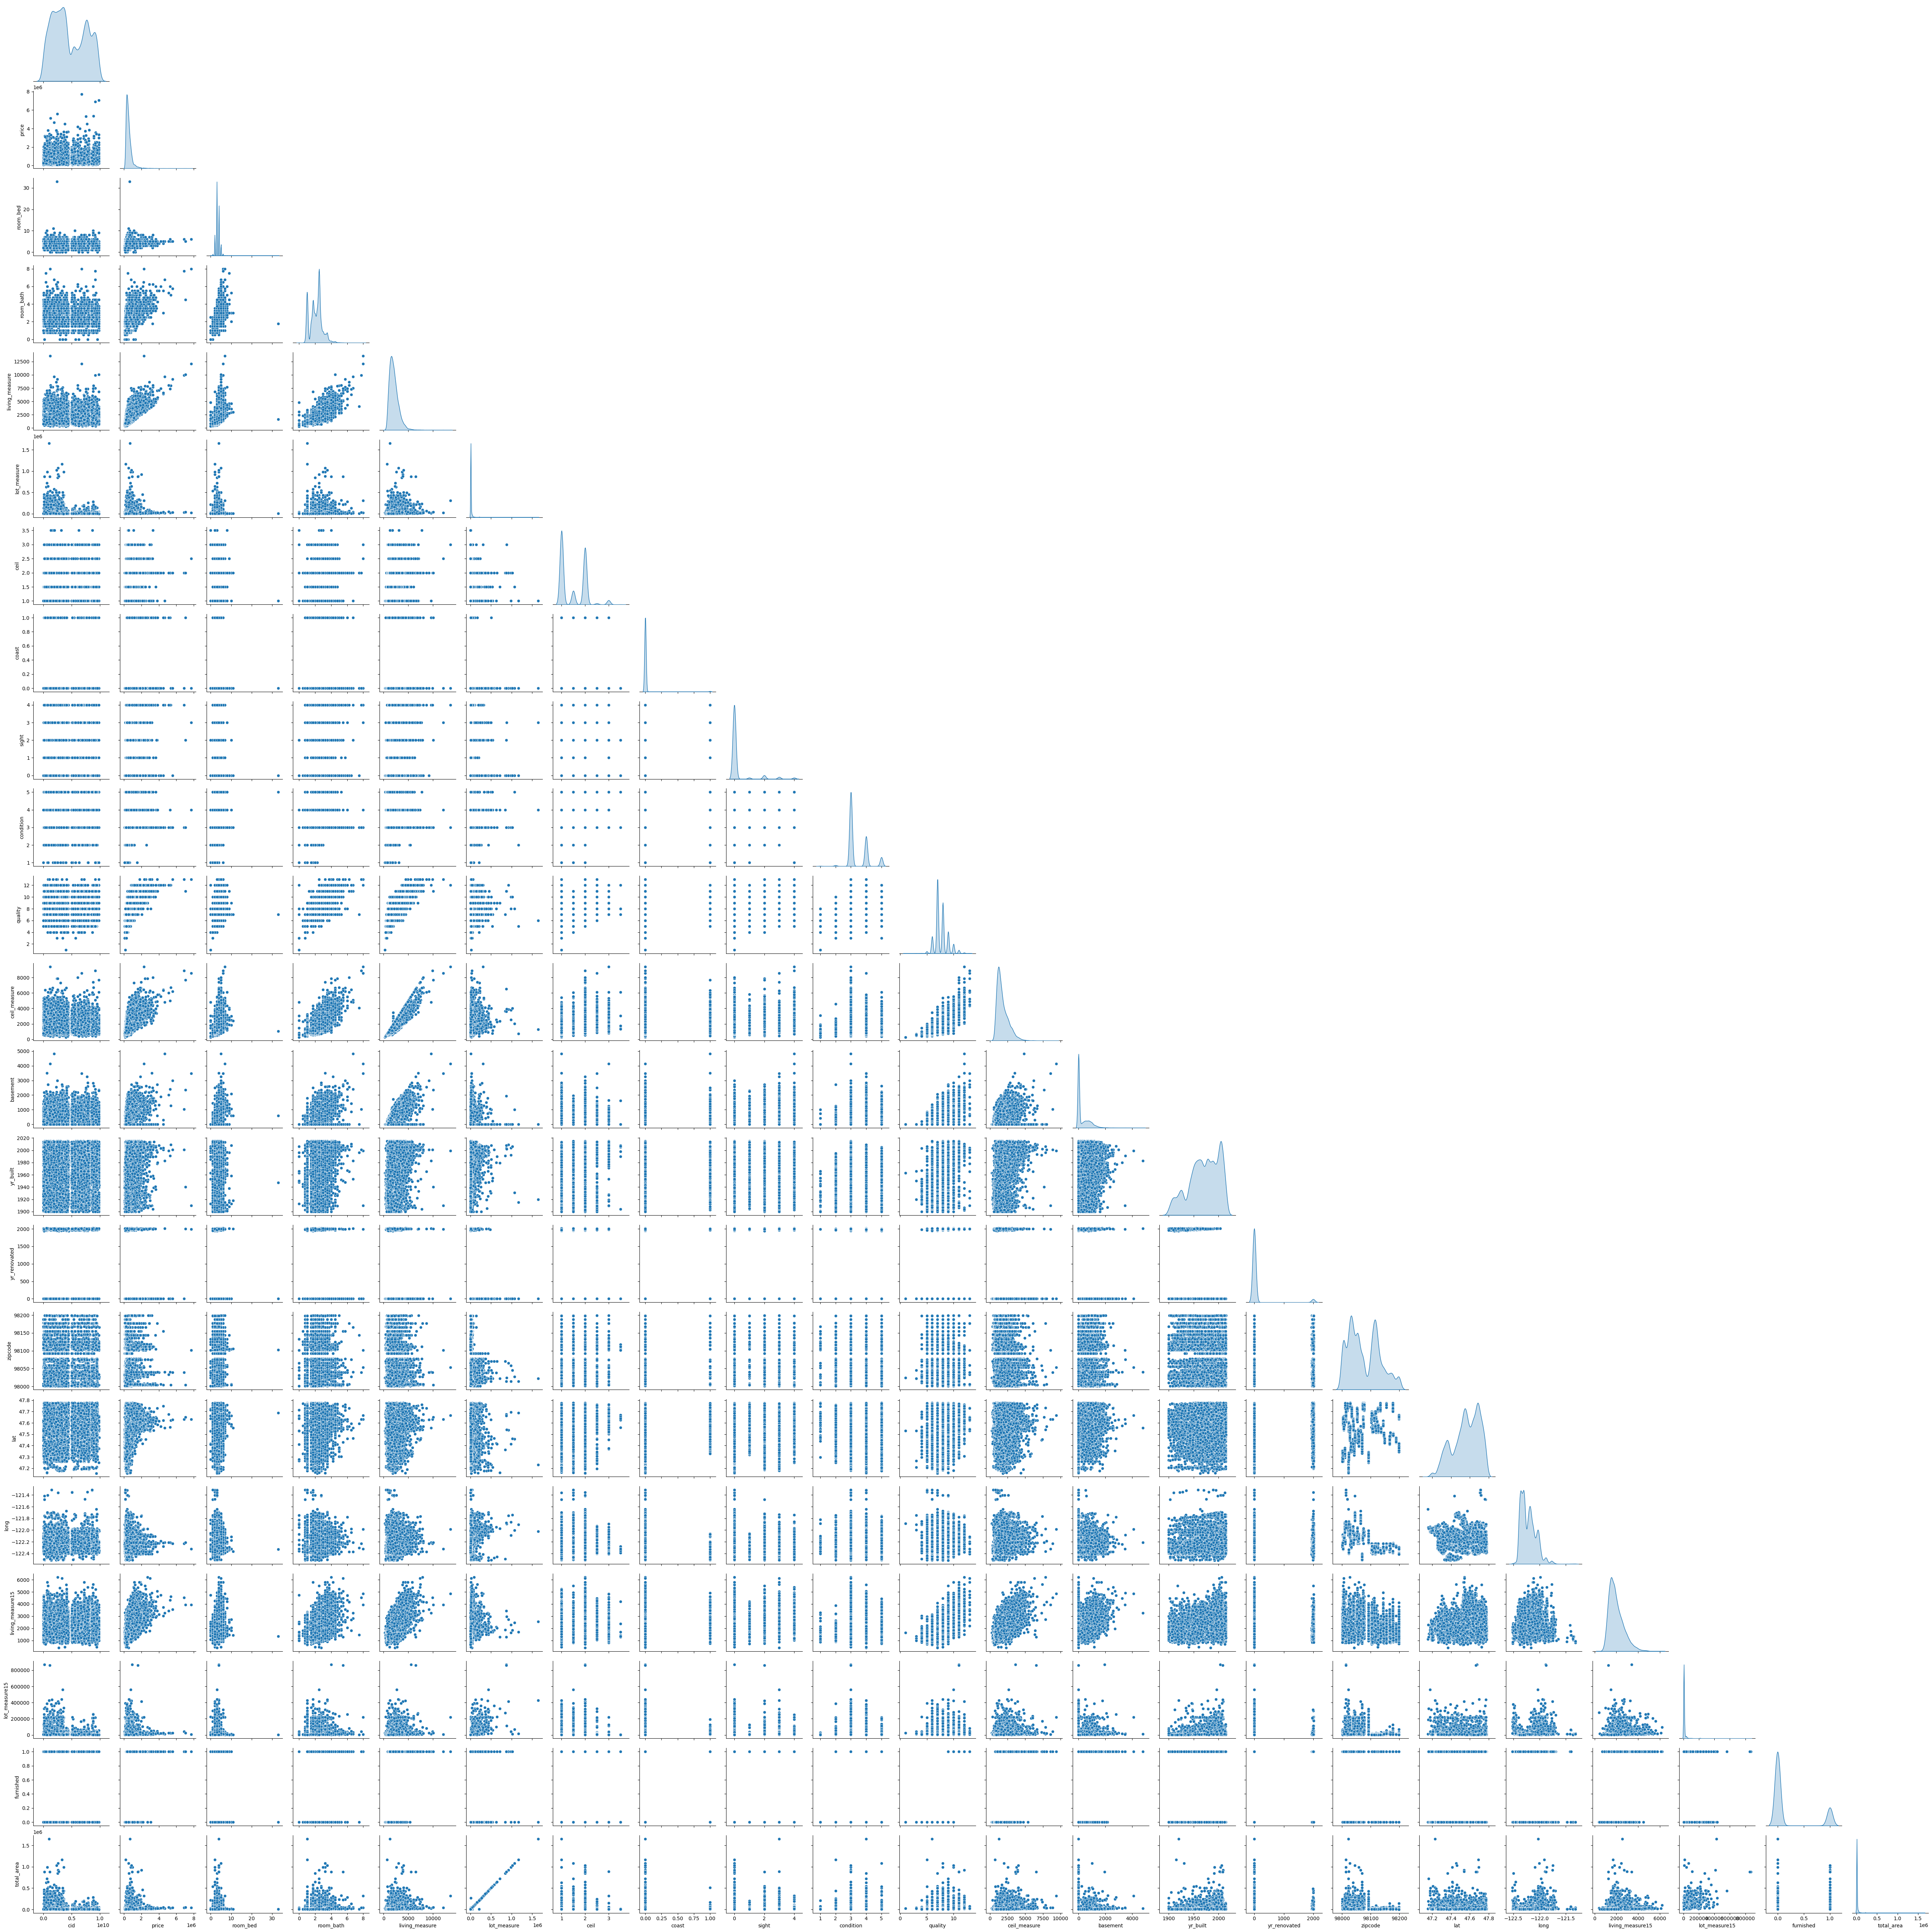

In [81]:
sns.pairplot(data=df,diag_kind='kde',corner=True)
plt.show()

# train_test_split

In [83]:
x=df.drop(['cid','dayhours','zipcode','price'],axis=1)
x

,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,yr_built,yr_renovated,lat,long,living_measure15,lot_measure15,furnished,total_area
0,4.0,1.75,3050.0,9440.0,1.0,0.0,0.0,3.0,8.0,1800.0,1250.0,1966.0,0,47.7228,-122.183,2020.0,8660.0,0.0,12490.0
1,2.0,1.00,670.0,3101.0,1.0,0.0,0.0,4.0,6.0,670.0,0.0,1948.0,0,47.5546,-122.274,1660.0,4100.0,0.0,3771.0
2,4.0,2.75,3040.0,2415.0,2.0,1.0,4.0,3.0,8.0,3040.0,0.0,1966.0,0,47.5188,-122.256,2620.0,2433.0,0.0,5455.0
3,3.0,2.50,1740.0,3721.0,2.0,0.0,0.0,3.0,8.0,1740.0,0.0,2009.0,0,47.3363,-122.213,2030.0,3794.0,0.0,5461.0
4,2.0,1.00,1120.0,4590.0,1.0,0.0,0.0,3.0,7.0,1120.0,0.0,1924.0,0,47.5663,-122.285,1120.0,5100.0,0.0,5710.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,4.0,2.50,3130.0,60467.0,2.0,0.0,0.0,3.0,9.0,3130.0,0.0,1996.0,0,47.6618,-121.962,2780.0,44224.0,1.0,63597.0
21609,2.0,1.00,1030.0,4841.0,1.0,0.0,0.0,3.0,7.0,920.0,110.0,1939.0,0,47.6860,-122.341,1530.0,4944.0,0.0,5871.0
21610,3.0,3.75,3710.0,34412.0,2.0,0.0,0.0,3.0,10.0,2910.0,800.0,1978.0,0,47.5888,-122.040,2390.0,34412.0,1.0,38122.0
21611,4.0,2.50,1560.0,7800.0,2.0,0.0,0.0,3.0,7.0,1560.0,0.0,1997.0,0,47.5140,-122.316,1160.0,7800.0,0.0,9360.0


In [84]:
y=df['price']
y

0         600000
1         190000
2         735000
3         257000
4         450000
          ...   
21608     685530
21609     535000
21610     998000
21611     262000
21612    1150000
Name: price, Length: 21613, dtype: int64

In [85]:
x=sm.add_constant(x)
x

,const,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,yr_built,yr_renovated,lat,long,living_measure15,lot_measure15,furnished,total_area
0,1.0,4.0,1.75,3050.0,9440.0,1.0,0.0,0.0,3.0,8.0,1800.0,1250.0,1966.0,0,47.7228,-122.183,2020.0,8660.0,0.0,12490.0
1,1.0,2.0,1.00,670.0,3101.0,1.0,0.0,0.0,4.0,6.0,670.0,0.0,1948.0,0,47.5546,-122.274,1660.0,4100.0,0.0,3771.0
2,1.0,4.0,2.75,3040.0,2415.0,2.0,1.0,4.0,3.0,8.0,3040.0,0.0,1966.0,0,47.5188,-122.256,2620.0,2433.0,0.0,5455.0
3,1.0,3.0,2.50,1740.0,3721.0,2.0,0.0,0.0,3.0,8.0,1740.0,0.0,2009.0,0,47.3363,-122.213,2030.0,3794.0,0.0,5461.0
4,1.0,2.0,1.00,1120.0,4590.0,1.0,0.0,0.0,3.0,7.0,1120.0,0.0,1924.0,0,47.5663,-122.285,1120.0,5100.0,0.0,5710.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,1.0,4.0,2.50,3130.0,60467.0,2.0,0.0,0.0,3.0,9.0,3130.0,0.0,1996.0,0,47.6618,-121.962,2780.0,44224.0,1.0,63597.0
21609,1.0,2.0,1.00,1030.0,4841.0,1.0,0.0,0.0,3.0,7.0,920.0,110.0,1939.0,0,47.6860,-122.341,1530.0,4944.0,0.0,5871.0
21610,1.0,3.0,3.75,3710.0,34412.0,2.0,0.0,0.0,3.0,10.0,2910.0,800.0,1978.0,0,47.5888,-122.040,2390.0,34412.0,1.0,38122.0
21611,1.0,4.0,2.50,1560.0,7800.0,2.0,0.0,0.0,3.0,7.0,1560.0,0.0,1997.0,0,47.5140,-122.316,1160.0,7800.0,0.0,9360.0


In [86]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [87]:
x

,const,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,yr_built,yr_renovated,lat,long,living_measure15,lot_measure15,furnished,total_area
0,1.0,4.0,1.75,3050.0,9440.0,1.0,0.0,0.0,3.0,8.0,1800.0,1250.0,1966.0,0,47.7228,-122.183,2020.0,8660.0,0.0,12490.0
1,1.0,2.0,1.00,670.0,3101.0,1.0,0.0,0.0,4.0,6.0,670.0,0.0,1948.0,0,47.5546,-122.274,1660.0,4100.0,0.0,3771.0
2,1.0,4.0,2.75,3040.0,2415.0,2.0,1.0,4.0,3.0,8.0,3040.0,0.0,1966.0,0,47.5188,-122.256,2620.0,2433.0,0.0,5455.0
3,1.0,3.0,2.50,1740.0,3721.0,2.0,0.0,0.0,3.0,8.0,1740.0,0.0,2009.0,0,47.3363,-122.213,2030.0,3794.0,0.0,5461.0
4,1.0,2.0,1.00,1120.0,4590.0,1.0,0.0,0.0,3.0,7.0,1120.0,0.0,1924.0,0,47.5663,-122.285,1120.0,5100.0,0.0,5710.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,1.0,4.0,2.50,3130.0,60467.0,2.0,0.0,0.0,3.0,9.0,3130.0,0.0,1996.0,0,47.6618,-121.962,2780.0,44224.0,1.0,63597.0
21609,1.0,2.0,1.00,1030.0,4841.0,1.0,0.0,0.0,3.0,7.0,920.0,110.0,1939.0,0,47.6860,-122.341,1530.0,4944.0,0.0,5871.0
21610,1.0,3.0,3.75,3710.0,34412.0,2.0,0.0,0.0,3.0,10.0,2910.0,800.0,1978.0,0,47.5888,-122.040,2390.0,34412.0,1.0,38122.0
21611,1.0,4.0,2.50,1560.0,7800.0,2.0,0.0,0.0,3.0,7.0,1560.0,0.0,1997.0,0,47.5140,-122.316,1160.0,7800.0,0.0,9360.0


In [88]:
olsmod_1=sm.OLS(y_train,x_train)
olsreg_1=olsmod_1.fit()
olsreg_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     1806.
Date:                Fri, 26 Dec 2025   Prob (F-statistic):               0.00
Time:                        11:41:08   Log-Likelihood:            -2.0637e+05
No. Observations:               15129   AIC:                         4.128e+05
Df Residuals:                   15109   BIC:                         4.129e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.706e+07    1.9e+06    -19.467      0.000   -4.08e+07   -3.33e+07
room_bed         -4.037e+04   2372.209    -17.020      0.000    -4.5e+04   -3.57e+04
room_bath         4.653e+04   3918.118     11.875      0.000    3.88e+04    5.42e+04
living_measure      92.8939     62.141      1.495      0.135     -28.910     214.698
lot_measure          0.1143      0.600      0.190      0.849      -1.063       1.291
ceil              2145.6731   4321.628      0.496      0.620   -6325.241    1.06e+04
coast             5.707e+05   2.14e+04     26.729      0.000    5.29e+05    6.13e+05
sight             5.066e+04   2534.736     19.988      0.000    4.57e+04    5.56e+04
condition         3.371e+04   2835.025     11.891      0.000    2.82e+04    3.93e+04
quality           8.135e+04   3078.430     26.426      0.000    7.53e+04    8.74e+04
ceil_measure        89.6516     62.153      1.442      0.149     -32.175     211.478
basement            60.8502     62.142      0.979      0.327     -60.955     182.655
yr_built         -2351.3163     87.523    -26.865      0.000   -2522.872   -2179.761
yr_renovated        26.0411      4.375      5.953      0.000      17.466      34.616
lat               5.565e+05   1.26e+04     44.145      0.000    5.32e+05    5.81e+05
long             -1.196e+05   1.43e+04     -8.368      0.000   -1.48e+05   -9.16e+04
living_measure15    27.9016      4.154      6.716      0.000      19.759      36.045
lot_measure15       -0.3633      0.087     -4.181      0.000      -0.534      -0.193
furnished         4.238e+04   6946.394      6.100      0.000    2.88e+04     5.6e+04
total_area          -0.0059      0.603     -0.010      0.992      -1.187       1.175
==============================================================================
Omnibus:                    13774.316   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1867167.528
Skew:                           3.895   Prob(JB):                         0.00
Kurtosis:                      56.864   Cond. No.                     7.95e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.95e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [89]:
x_train.shape

(15129, 20)

In [90]:
y_train.shape

(15129,)

In [91]:
x_test.shape

(6484, 20)

In [92]:
y_test.shape

(6484,)

# checking for multicollinearity using vif method

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [94]:
vif=[]
for i in range(0,20):
    viff=variance_inflation_factor(x_train,i)
    vif.append(viff)
vif

[np.float64(1326856.8798362124),
 np.float64(1.6983719787563154),
 np.float64(3.3617239221925037),
 np.float64(1194.6056814223004),
 np.float64(240.19000607598446),
 np.float64(1.9840417023724768),
 np.float64(1.1826026132361027),
 np.float64(1.399232391618452),
 np.float64(1.2414609416454185),
 np.float64(4.7983438118364985),
 np.float64(970.3569303840853),
 np.float64(276.7788849675282),
 np.float64(2.41646738400447),
 np.float64(1.1543035673540158),
 np.float64(1.1263029598767538),
 np.float64(1.4925487203998917),
 np.float64(2.9441289467568463),
 np.float64(2.109129297957251),
 np.float64(2.8042361565841523),
 np.float64(243.99650855897158)]

In [96]:
vif=pd.Series(vif,index=x_train.columns)
vif

const               1.326857e+06
room_bed            1.698372e+00
room_bath           3.361724e+00
living_measure      1.194606e+03
lot_measure         2.401900e+02
ceil                1.984042e+00
coast               1.182603e+00
sight               1.399232e+00
condition           1.241461e+00
quality             4.798344e+00
ceil_measure        9.703569e+02
basement            2.767789e+02
yr_built            2.416467e+00
yr_renovated        1.154304e+00
lat                 1.126303e+00
long                1.492549e+00
living_measure15    2.944129e+00
lot_measure15       2.109129e+00
furnished           2.804236e+00
total_area          2.439965e+02
dtype: float64

In [97]:
x_train2=x_train.drop('living_measure',axis=1)
olsmod_2=sm.OLS(y_train,x_train2)
olsreg_2=olsmod_2.fit()
print(
    "R-squared:", np.round(olsreg_2.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_2.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [98]:
x_train3=x_train.drop("lot_measure",axis=1)
olsmod_3=sm.OLS(y_train,x_train3)
olsreg_3=olsmod_3.fit()
print(
    "R-squared:", np.round(olsreg_3.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_3.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [101]:
x_train4=x_train.drop("ceil_measure",axis=1)
olsmod_4=sm.OLS(y_train,x_train4)
olsreg_4=olsmod_4.fit()
print(
    "R-squared:",np.round(olsreg_4.rsquared,3),
    "\nAdjusted R_squared:",np.round(olsreg_4.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R_squared: 0.694


In [102]:
x_train5=x_train.drop("basement",axis=1)
olsmod_5=sm.OLS(y_train,x_train5)
olsreg_5=olsmod_5.fit()
print(
    "R-squared:", np.round(olsreg_5.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_5.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [103]:
x_train6=x_train.drop("total_area",axis=1)
olsmod_6=sm.OLS(y_train,x_train6)
olsreg_6=olsmod_6.fit()
print(
    "R-squared:", np.round(olsreg_6.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_6.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [104]:
x_train=x_train.drop("total_area",axis=1)
x_train

,const,room_bed,room_bath,living_measure,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,yr_built,yr_renovated,lat,long,living_measure15,lot_measure15,furnished
2060,1.0,2.0,2.50,1830.0,2856.0,2.0,0.0,0.0,3.0,7.0,1830.0,0.0,2005.0,0,47.5524,-121.996,1850.0,2667.0,0.0
11759,1.0,2.0,1.00,1380.0,5820.0,1.0,0.0,0.0,3.0,7.0,1380.0,0.0,1918.0,1976,47.6875,-122.392,1540.0,4076.0,0.0
8274,1.0,2.0,1.00,1130.0,6908.0,1.5,0.0,0.0,3.0,6.0,1130.0,0.0,1945.0,0,47.7450,-122.313,1150.0,6908.0,0.0
21272,1.0,3.0,2.25,1820.0,13362.0,1.0,0.0,0.0,3.0,8.0,1220.0,600.0,1977.0,0,47.5898,-122.052,2050.0,15000.0,0.0
14328,1.0,3.0,1.50,1660.0,7221.0,1.0,0.0,0.0,3.0,7.0,980.0,680.0,1962.0,0,47.4962,-122.320,1770.0,8083.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,1.0,5.0,3.00,1810.0,3000.0,2.0,0.0,0.0,3.0,7.0,1810.0,0.0,1998.0,0,47.5622,-122.291,1670.0,3000.0,0.0
17289,1.0,4.0,1.75,1920.0,7700.0,2.0,0.0,0.0,4.0,7.0,1920.0,0.0,1970.0,0,47.5381,-122.177,1310.0,7700.0,0.0
5192,1.0,4.0,3.25,3420.0,5012.0,2.0,0.0,0.0,3.0,10.0,2330.0,1090.0,2008.0,0,47.7320,-121.982,2320.0,5465.0,1.0
12172,1.0,4.0,1.75,2140.0,8162.0,1.0,0.0,0.0,3.0,7.0,1420.0,720.0,1968.0,0,47.3096,-122.377,2040.0,7632.0,0.0


In [105]:
olsmod7=sm.OLS(y_train,x_train)
olsreg7=olsmod7.fit()
olsreg7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     1907.
Date:                Fri, 26 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:11:01   Log-Likelihood:            -2.0637e+05
No. Observations:               15129   AIC:                         4.128e+05
Df Residuals:                   15110   BIC:                         4.129e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.706e+07    1.9e+06    -19.468      0.000   -4.08e+07   -3.33e+07
room_bed         -4.037e+04   2372.130    -17.021      0.000    -4.5e+04   -3.57e+04
room_bath         4.653e+04   3917.944     11.876      0.000    3.89e+04    5.42e+04
living_measure      92.8938     62.139      1.495      0.135     -28.906     214.693
lot_measure          0.1085      0.055      1.957      0.050      -0.000       0.217
ceil              2145.1520   4321.152      0.496      0.620   -6324.829    1.06e+04
coast             5.707e+05   2.13e+04     26.730      0.000    5.29e+05    6.13e+05
sight             5.066e+04   2534.633     19.989      0.000    4.57e+04    5.56e+04
condition         3.371e+04   2834.930     11.891      0.000    2.82e+04    3.93e+04
quality           8.135e+04   3078.071     26.429      0.000    7.53e+04    8.74e+04
ceil_measure        89.6456     62.147      1.442      0.149     -32.171     211.462
basement            60.8442     62.136      0.979      0.327     -60.951     182.639
yr_built         -2351.3167     87.520    -26.866      0.000   -2522.867   -2179.767
yr_renovated        26.0411      4.375      5.953      0.000      17.466      34.616
lat               5.565e+05   1.26e+04     44.151      0.000    5.32e+05    5.81e+05
long             -1.196e+05   1.43e+04     -8.369      0.000   -1.48e+05   -9.16e+04
living_measure15    27.9018      4.154      6.717      0.000      19.759      36.045
lot_measure15       -0.3634      0.087     -4.200      0.000      -0.533      -0.194
furnished         4.238e+04   6946.083      6.101      0.000    2.88e+04     5.6e+04
==============================================================================
Omnibus:                    13774.317   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1867168.151
Skew:                           3.895   Prob(JB):                         0.00
Kurtosis:                      56.864   Cond. No.                     5.95e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.95e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [106]:
x_train.shape

(15129, 19)

In [107]:
vif=[]
for i in range(0,19):
    viff=variance_inflation_factor(x_train.values,i)
    vif.append(viff)
vif

[np.float64(1326852.1033919246),
 np.float64(1.6983717835651517),
 np.float64(3.3616484195574916),
 np.float64(1194.6056438934068),
 np.float64(2.0468450375793314),
 np.float64(1.9837358077087652),
 np.float64(1.1826024693004697),
 np.float64(1.399211848095008),
 np.float64(1.2414598380534614),
 np.float64(4.797541575297641),
 np.float64(970.2607860269012),
 np.float64(276.75106438643525),
 np.float64(2.4164666729600466),
 np.float64(1.1543003455280365),
 np.float64(1.1260416001318863),
 np.float64(1.4924703755270774),
 np.float64(2.9440820257402227),
 np.float64(2.0907584371859227),
 np.float64(2.8041700537563963)]

In [108]:
vif=pd.Series(vif,index=x_train.columns)
vif

const               1.326852e+06
room_bed            1.698372e+00
room_bath           3.361648e+00
living_measure      1.194606e+03
lot_measure         2.046845e+00
ceil                1.983736e+00
coast               1.182602e+00
sight               1.399212e+00
condition           1.241460e+00
quality             4.797542e+00
ceil_measure        9.702608e+02
basement            2.767511e+02
yr_built            2.416467e+00
yr_renovated        1.154300e+00
lat                 1.126042e+00
long                1.492470e+00
living_measure15    2.944082e+00
lot_measure15       2.090758e+00
furnished           2.804170e+00
dtype: float64

In [109]:
x_train8=x_train.drop('living_measure',axis=1)
olsmod_8=sm.OLS(y_train,x_train8)
olsreg_8=olsmod_8.fit()
print(
    "R-squared:", np.round(olsreg_8.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_8.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [110]:
x_train9=x_train.drop("ceil_measure",axis=1)
olsmod_9=sm.OLS(y_train,x_train9)
olsreg_9=olsmod_9.fit()
print(
    "R-squared:", np.round(olsreg_9.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_9.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [111]:
x_train10=x_train.drop("basement",axis=1)
olsmod_10=sm.OLS(y_train,x_train10)
olsreg_10=olsmod_10.fit()
print(
    "R-squared:", np.round(olsreg_10.rsquared,3),
    "\nAdjusted R-squared:", np.round(olsreg_10.rsquared_adj,3),
)

R-squared: 0.694 
Adjusted R-squared: 0.694


In [112]:
x_train=x_train.drop("living_measure",axis=1)
x_train

,const,room_bed,room_bath,lot_measure,ceil,coast,sight,condition,quality,ceil_measure,basement,yr_built,yr_renovated,lat,long,living_measure15,lot_measure15,furnished
2060,1.0,2.0,2.50,2856.0,2.0,0.0,0.0,3.0,7.0,1830.0,0.0,2005.0,0,47.5524,-121.996,1850.0,2667.0,0.0
11759,1.0,2.0,1.00,5820.0,1.0,0.0,0.0,3.0,7.0,1380.0,0.0,1918.0,1976,47.6875,-122.392,1540.0,4076.0,0.0
8274,1.0,2.0,1.00,6908.0,1.5,0.0,0.0,3.0,6.0,1130.0,0.0,1945.0,0,47.7450,-122.313,1150.0,6908.0,0.0
21272,1.0,3.0,2.25,13362.0,1.0,0.0,0.0,3.0,8.0,1220.0,600.0,1977.0,0,47.5898,-122.052,2050.0,15000.0,0.0
14328,1.0,3.0,1.50,7221.0,1.0,0.0,0.0,3.0,7.0,980.0,680.0,1962.0,0,47.4962,-122.320,1770.0,8083.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,1.0,5.0,3.00,3000.0,2.0,0.0,0.0,3.0,7.0,1810.0,0.0,1998.0,0,47.5622,-122.291,1670.0,3000.0,0.0
17289,1.0,4.0,1.75,7700.0,2.0,0.0,0.0,4.0,7.0,1920.0,0.0,1970.0,0,47.5381,-122.177,1310.0,7700.0,0.0
5192,1.0,4.0,3.25,5012.0,2.0,0.0,0.0,3.0,10.0,2330.0,1090.0,2008.0,0,47.7320,-121.982,2320.0,5465.0,1.0
12172,1.0,4.0,1.75,8162.0,1.0,0.0,0.0,3.0,7.0,1420.0,720.0,1968.0,0,47.3096,-122.377,2040.0,7632.0,0.0


In [113]:
olsmod11=sm.OLS(y_train,x_train)
olsreg11=olsmod11.fit()
olsreg11.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     2018.
Date:                Fri, 26 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:27:29   Log-Likelihood:            -2.0637e+05
No. Observations:               15129   AIC:                         4.128e+05
Df Residuals:                   15111   BIC:                         4.129e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.708e+07    1.9e+06    -19.473      0.000   -4.08e+07   -3.33e+07
room_bed         -4.032e+04   2371.938    -16.999      0.000    -4.5e+04   -3.57e+04
room_bath         4.674e+04   3915.596     11.937      0.000    3.91e+04    5.44e+04
lot_measure          0.1086      0.055      1.959      0.050   -5.45e-05       0.217
ceil              2071.0087   4321.044      0.479      0.632   -6398.760    1.05e+04
coast             5.709e+05   2.14e+04     26.742      0.000    5.29e+05    6.13e+05
sight             5.064e+04   2534.686     19.979      0.000    4.57e+04    5.56e+04
condition         3.371e+04   2835.046     11.891      0.000    2.82e+04    3.93e+04
quality           8.133e+04   3078.171     26.422      0.000    7.53e+04    8.74e+04
ceil_measure       182.3142      4.446     41.003      0.000     173.599     191.030
basement           153.3993      5.274     29.087      0.000     143.062     163.736
yr_built         -2352.9251     87.517    -26.885      0.000   -2524.469   -2181.381
yr_renovated        25.9717      4.375      5.937      0.000      17.397      34.546
lat               5.567e+05   1.26e+04     44.167      0.000    5.32e+05    5.81e+05
long             -1.196e+05   1.43e+04     -8.371      0.000   -1.48e+05   -9.16e+04
living_measure15    27.9946      4.154      6.739      0.000      19.852      36.137
lot_measure15       -0.3628      0.087     -4.193      0.000      -0.532      -0.193
furnished         4.241e+04   6946.334      6.105      0.000    2.88e+04     5.6e+04
==============================================================================
Omnibus:                    13778.566   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1869436.547
Skew:                           3.897   Prob(JB):                         0.00
Kurtosis:                      56.897   Cond. No.                     5.95e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.95e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [114]:
x_train.shape

(15129, 18)

In [115]:
vif=[]
for i in range(0,18):
    viff=variance_inflation_factor(x_train.values,i)
    vif.append(viff)
vif

[np.float64(1326832.1586832),
 np.float64(1.697957476997535),
 np.float64(3.3573459540617785),
 np.float64(2.0468414631622944),
 np.float64(1.9834744821004928),
 np.float64(1.1825298150964922),
 np.float64(1.3991562491974985),
 np.float64(1.2414597252156707),
 np.float64(4.797461851689732),
 np.float64(4.966162154247384),
 np.float64(1.9934243410328347),
 np.float64(2.416101520143274),
 np.float64(1.1541702854874054),
 np.float64(1.1259170156075098),
 np.float64(1.492465529277497),
 np.float64(2.9434252225175603),
 np.float64(2.0907140878891886),
 np.float64(2.804144173137803)]

In [116]:
vif=pd.Series(vif,index=x_train.columns)
vif

const               1.326832e+06
room_bed            1.697957e+00
room_bath           3.357346e+00
lot_measure         2.046841e+00
ceil                1.983474e+00
coast               1.182530e+00
sight               1.399156e+00
condition           1.241460e+00
quality             4.797462e+00
ceil_measure        4.966162e+00
basement            1.993424e+00
yr_built            2.416102e+00
yr_renovated        1.154170e+00
lat                 1.125917e+00
long                1.492466e+00
living_measure15    2.943425e+00
lot_measure15       2.090714e+00
furnished           2.804144e+00
dtype: float64

# dropping highest p value

In [117]:
x_train=x_train.drop("ceil",axis=1)
olsmod_12=sm.OLS(y_train,x_train)
olsreg_12=olsmod_12.fit()
olsreg_12.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     2145.
Date:                Fri, 26 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:31:24   Log-Likelihood:            -2.0637e+05
No. Observations:               15129   AIC:                         4.128e+05
Df Residuals:                   15112   BIC:                         4.129e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.724e+07   1.87e+06    -19.873      0.000   -4.09e+07   -3.36e+07
room_bed         -4.037e+04   2369.930    -17.032      0.000    -4.5e+04   -3.57e+04
room_bath         4.722e+04   3782.297     12.486      0.000    3.98e+04    5.46e+04
lot_measure          0.1082      0.055      1.952      0.051      -0.000       0.217
coast              5.71e+05   2.13e+04     26.749      0.000    5.29e+05    6.13e+05
sight             5.068e+04   2533.375     20.004      0.000    4.57e+04    5.56e+04
condition         3.363e+04   2830.440     11.883      0.000    2.81e+04    3.92e+04
quality           8.143e+04   3071.485     26.511      0.000    7.54e+04    8.74e+04
ceil_measure       182.6805      4.380     41.707      0.000     174.095     191.266
basement           152.6503      5.037     30.307      0.000     142.778     162.523
yr_built         -2344.1692     85.587    -27.389      0.000   -2511.930   -2176.409
yr_renovated        26.0856      4.368      5.972      0.000      17.524      34.647
lat               5.573e+05   1.25e+04     44.452      0.000    5.33e+05    5.82e+05
long             -1.206e+05   1.42e+04     -8.522      0.000   -1.48e+05   -9.29e+04
living_measure15    27.7568      4.124      6.730      0.000      19.673      35.840
lot_measure15       -0.3642      0.086     -4.212      0.000      -0.534      -0.195
furnished         4.239e+04   6946.060      6.103      0.000    2.88e+04     5.6e+04
==============================================================================
Omnibus:                    13766.278   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1863115.922
Skew:                           3.892   Prob(JB):                         0.00
Kurtosis:                      56.805   Cond. No.                     5.86e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.86e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# equation

In [118]:
olsreg_12.params

const              -3.723715e+07
room_bed           -4.036558e+04
room_bath           4.722461e+04
lot_measure         1.081998e-01
coast               5.710440e+05
sight               5.067831e+04
condition           3.363438e+04
quality             8.142904e+04
ceil_measure        1.826805e+02
basement            1.526503e+02
yr_built           -2.344169e+03
yr_renovated        2.608559e+01
lat                 5.573407e+05
long               -1.205968e+05
living_measure15    2.775677e+01
lot_measure15      -3.642071e-01
furnished           4.238986e+04
dtype: float64

In [120]:
Equation="price="
print(Equation)
for i in range(len(x_train.columns)):
    if i == 0:
        print(olsreg_12.params[i],"+",end=" ")
    elif i > 0:
        print(olsreg_12.params[i],"* (",x_train.columns[i],")","+",end=" ") 

price=
-37237153.3048046 + -40365.57763810152 * ( room_bed ) + 47224.61376670716 * ( room_bath ) + 0.10819983191248264 * ( lot_measure ) + 571043.9795161857 * ( coast ) + 50678.30902695372 * ( sight ) + 33634.38048892113 * ( condition ) + 81429.04091214549 * ( quality ) + 182.6804763890863 * ( ceil_measure ) + 152.65025811702714 * ( basement ) + -2344.1691894135465 * ( yr_built ) + 26.085588842533483 * ( yr_renovated ) + 557340.669337299 * ( lat ) + -120596.84753569271 * ( long ) + 27.756770451381666 * ( living_measure15 ) + -0.36420708839187094 * ( lot_measure15 ) + 42389.86314050079 * ( furnished ) + 

C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\3411143992.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsreg_12.params[i],"+",end=" ")
C:\Users\Welcome\AppData\Local\Temp\ipykernel_23200\3411143992.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsreg_12.params[i],"* (",x_train.columns[i],")","+",end=" ")


# prediction

In [121]:
x_train.columns

Index(['const', 'room_bed', 'room_bath', 'lot_measure', 'coast', 'sight',
       'condition', 'quality', 'ceil_measure', 'basement', 'yr_built',
       'yr_renovated', 'lat', 'long', 'living_measure15', 'lot_measure15',
       'furnished'],
      dtype='object')

In [122]:
x_test.columns

Index(['const', 'room_bed', 'room_bath', 'living_measure', 'lot_measure',
       'ceil', 'coast', 'sight', 'condition', 'quality', 'ceil_measure',
       'basement', 'yr_built', 'yr_renovated', 'lat', 'long',
       'living_measure15', 'lot_measure15', 'furnished', 'total_area'],
      dtype='object')

In [127]:
x_test = x_test.drop(
    ["living_measure", "ceil", "total_area"],
    axis=1,
    errors="ignore"
)


In [128]:
x_test

,const,room_bed,room_bath,lot_measure,coast,sight,condition,quality,ceil_measure,basement,yr_built,yr_renovated,lat,long,living_measure15,lot_measure15,furnished
15544,1.0,3.0,2.75,12240.0,0.0,0.0,3.0,7.0,1250.0,700.0,1956.0,0,47.7401,-122.258,1880.0,12000.0,0.0
17454,1.0,4.0,2.50,52272.0,0.0,0.0,2.0,8.0,2340.0,0.0,1978.0,0,47.3468,-122.091,2480.0,40500.0,0.0
21548,1.0,4.0,2.50,7685.0,0.0,0.0,3.0,9.0,3360.0,0.0,2001.0,0,47.4369,-122.111,3060.0,6567.0,1.0
3427,1.0,4.0,2.75,5000.0,0.0,0.0,5.0,8.0,1480.0,830.0,1908.0,0,47.5502,-122.268,1100.0,5000.0,0.0
8809,1.0,2.0,1.00,6500.0,0.0,0.0,4.0,6.0,800.0,0.0,1953.0,0,47.7621,-122.358,1220.0,7000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14866,1.0,3.0,1.75,82328.0,0.0,0.0,3.0,7.0,1560.0,0.0,1974.0,0,47.3674,-122.503,2100.0,205603.0,0.0
4903,1.0,4.0,2.75,7210.0,0.0,0.0,4.0,7.0,1600.0,940.0,1979.0,0,47.4601,-122.165,1820.0,7766.0,0.0
16080,1.0,3.0,2.50,6033.0,0.0,0.0,4.0,7.0,1770.0,0.0,1987.0,0,47.3764,-122.119,1590.0,6510.0,0.0
15668,1.0,4.0,2.75,7495.0,0.0,0.0,4.0,7.0,1200.0,500.0,1964.0,0,47.7589,-122.354,1650.0,7495.0,0.0


In [129]:
x_train.shape

(15129, 17)

In [131]:
y_pred=olsreg_12.predict(x_test)

In [132]:
y_pred

15544    593100.203246
17454    400681.806138
21548    766814.876585
3427     751296.368966
8809     328200.838268
             ...      
14866    218460.085637
4903     465088.850619
16080    304208.526344
15668    544750.166612
18802    382184.270849
Length: 6484, dtype: float64

# ROOT MEAN SQUARE ERROR AND ABSOLUTE MEAN ERROR

In [133]:
olsreg_12.fittedvalues

2060     371236.709515
11759    587937.431248
8274     356781.663570
21272    476080.120922
14328    336999.601868
             ...      
10955    322443.947999
17289    384769.106406
5192     973967.450279
12172    291495.235343
235      761667.648661
Length: 15129, dtype: float64

In [134]:
y_train

2060     524950
11759    320000
8274     325000
21272    515000
14328    225000
          ...  
10955    362000
17289    415000
5192     548000
12172    292500
235      698000
Name: price, Length: 15129, dtype: int64

In [135]:
rmse1=np.sqrt(mean_squared_error(y_train,olsreg_12.fittedvalues))
rmse1

np.float64(203186.8543072693)

In [136]:
rmse2=np.sqrt(mean_squared_error(y_test,y_pred))
rmse2

np.float64(201177.8405251732)

In [137]:
mae1=mean_absolute_error(y_train,olsreg_12.fittedvalues)
mae1

125957.78793875496

In [138]:
mae2=mean_absolute_error(y_test,y_pred)
mae2

125785.2005253622